In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [4]:
import pickle
# with open('color_dict.pkl', 'wb') as file:  # Use 'wb' to open the file in write-binary mode
#     pickle.dump(color_dict, file)
with open('../color_dict.pkl', 'rb') as file:  # Use 'rb' to open the file in read-binary mode
    color_dict = pickle.load(file)


In [7]:
import logging
import sys

def configure_logging(logger_name):
    LOG_LEVEL = logging.DEBUG
    log_filename = logger_name+'.log'
    importer_logger = logging.getLogger('importer_logger')
    importer_logger.setLevel(LOG_LEVEL)
    formatter = logging.Formatter('%(asctime)s : %(levelname)s : %(message)s')

    fh = logging.FileHandler(filename=log_filename)
    fh.setLevel(LOG_LEVEL)
    fh.setFormatter(formatter)
    importer_logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setLevel(LOG_LEVEL)
    sh.setFormatter(formatter)
    importer_logger.addHandler(sh)
    return importer_logger

In [8]:
save_path = './logs'
save_path = Path(save_path)
loggings = configure_logging(str(save_path) + '/VUHD116A')


In [11]:
normal_samples = [
    'VUHD113', 
    'VUHD069', 'VUHD038', 'VUHD049', 
    'VUHD116A', 
    'VUHD116B', 'VUHD095', 'VUHD090'
]
disease_samples = [
    'VUILD91LA', 'VUILD48LA2', 'VUILD102LA', 'VUILD48LA1', 
    'VUILD106MA', 
    'VUILD105MA1', 
    'VUILD107MA', 
    'VUILD96MA', 'VUILD104MA1', 
    'VUILD102MA', 'VUILD142MA', 'VUILD96LA', 'VUILD141MA', 
    'VUILD58MA', 'VUILD91MA', 'VUILD49LA', 'VUILD78LA', 
    'VUILD110LA', 'VUILD105MA2', 
    'VUILD115MA', 
    'VUILD78MA', 'VUILD104MA2'
]
sample_all = normal_samples + disease_samples

In [10]:
sample = 'VUHD116A'

In [9]:
base_path = '/home/share/xwanaf/Img2Expr/data/lung_HLCA/Xenium_Vannan'
image_path = base_path + '/HE'  

HE_file_names = os.listdir(image_path)
loggings.info(f'length of all HE: {len(HE_file_names)}')

2026-03-26 18:39:45,182 : INFO : length of all HE: 28


## Load data

In [20]:
#==================================== load image ====================================#
from PIL import Image, ImageDraw
from skimage import io
import pandas as pd

HE_file_name = [_ for _ in HE_file_names if sample in _]

################
# read img 
################
loggings.info(f'reading img ... ')
image = io.imread(Path(image_path) / HE_file_name[0])
loggings.info(f'HE image shape: {image.shape}')


 #==================================== load sp_log ====================================#
loggings.info(f'reading sp_log ... ')
sp_base_path = '/home/share/xwanaf/Img2Expr/data/lung_HLCA/Xenium_Vannan'
sp_data_path = Path(sp_base_path) / 'parquet_all_samples_pretrainV4' / f'{sample}_1e3'
data_file_name = f'{sample}_raw_log.h5ad'

sp_log = sc.read(sp_data_path / data_file_name)

sp_inte_data_path = Path(sp_base_path) / 'Vannan_inte_pretrainV4' 
data_file_name = f'adata_inte_{sample}.h5ad'
sp_inte = sc.read(sp_inte_data_path / data_file_name)
sp_inte.obs.index = sp_log.obs.index[sp_inte.obs['cell_id'].astype(int)]
sp_log.obsm['inte'] = sp_inte[sp_log.obs.index].X


sf = np.load('Xenium_sf.npy').item()
loggings.info(f'sf: {sf}')
from einops import rearrange
uns_dict = {}
uns_dict['spatial'] = {}
uns_dict['spatial']['lung'] = {}
uns_dict['spatial']['lung']['images'] = {}
uns_dict['spatial']['lung']['images']['hires'] = image 
uns_dict['spatial']['lung']['scalefactors'] = {}
uns_dict['spatial']['lung']['scalefactors']['spot_diameter_fullres'] = 10
uns_dict['spatial']['lung']['scalefactors']['tissue_hires_scalef'] = sf

sp_log.uns['spatial'] = uns_dict['spatial']
sp_log.obsm['spatial'] = sp_log.obs.loc[:, ['x_centroid', 'y_centroid']].values


2026-03-26 18:45:34,043 : INFO : reading img ... 
2026-03-26 18:45:34,513 : INFO : HE image shape: (16598, 14301, 3)
2026-03-26 18:45:34,514 : INFO : reading sp_log ... 
2026-03-26 18:45:34,881 : INFO : sf: 4.7058820724487305


## Load cell type

In [21]:
#######################################
###### map2 atlas
#######################################
map_results_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF/spatial_annotation/fitted_spatial_nn'
file_insert = 'Disease' if sample in disease_samples else 'Normal'

map_results_file_name = f'{sample}_{file_insert}/adata_inte_mapped.h5ad'
mapped_adata = sc.read_h5ad(Path(map_results_path) / map_results_file_name, backed = 'r')
cell_id_Xe_index = [int(_.split('_')[-1]) for _ in mapped_adata.obs.index]
mapped_adata.obs.index = sp_log.obs.index[cell_id_Xe_index]
pred_col_map = f'predict_mapped_ct_anno'
mapped_adata = mapped_adata[mapped_adata.obs[f'{pred_col_map}_prob'] > .5]
sp_log.obs = sp_log.obs.merge(
    mapped_adata.obs[[pred_col_map, f'{pred_col_map}_prob']], 
    how = 'left',
    left_index = True, 
    right_index = True, suffixes = (None, '_y')
)
sp_log.obs = sp_log.obs.rename(columns = {pred_col_map: 'pred_atlas'})



In [22]:
sp_log

AnnData object with n_obs × n_vars = 12372 × 341
    obs: 'sample', 'patient', 'cell_id', 'sample_type', 'sample_affect', 'disease_status', 'percent_pathology', 'tma', 'run', 'final_CT', 'final_lineage', 'CNiche', 'TNiche', 'lumen_id', 'lumen_rank', 'x_centroid', 'y_centroid', 'adj_x_centroid', 'adj_y_centroid', 'super_adj_x_centroid', 'super_adj_y_centroid', 'nCount_RNA', 'nFeature_RNA', 'perc_negcontrolprobe', 'perc_negcontrolcodeword', 'perc_unassigned', 'perc_negcontrolorunassigned', 'n_genes', 'pred_atlas', 'predict_mapped_ct_anno_prob'
    var: 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'inte', 'spatial'

In [29]:
######################## UGE of ST data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 0.85))

traingene_base_path = Path('/import/home2/xwanaf/Img2Expr/data/lung_HLCA/pretrain_v4')
train_genes = np.load(traingene_base_path / 'pretrain_data_train_genes.npy')

pred_col = 'pred_atlas'

adata_inte = sc.AnnData(sp_log.obsm['inte'], obs = sp_log.obs, var = pd.DataFrame(index = train_genes))
adata_inte.uns = sp_log.uns
adata_inte.obsm = sp_log.obsm


/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


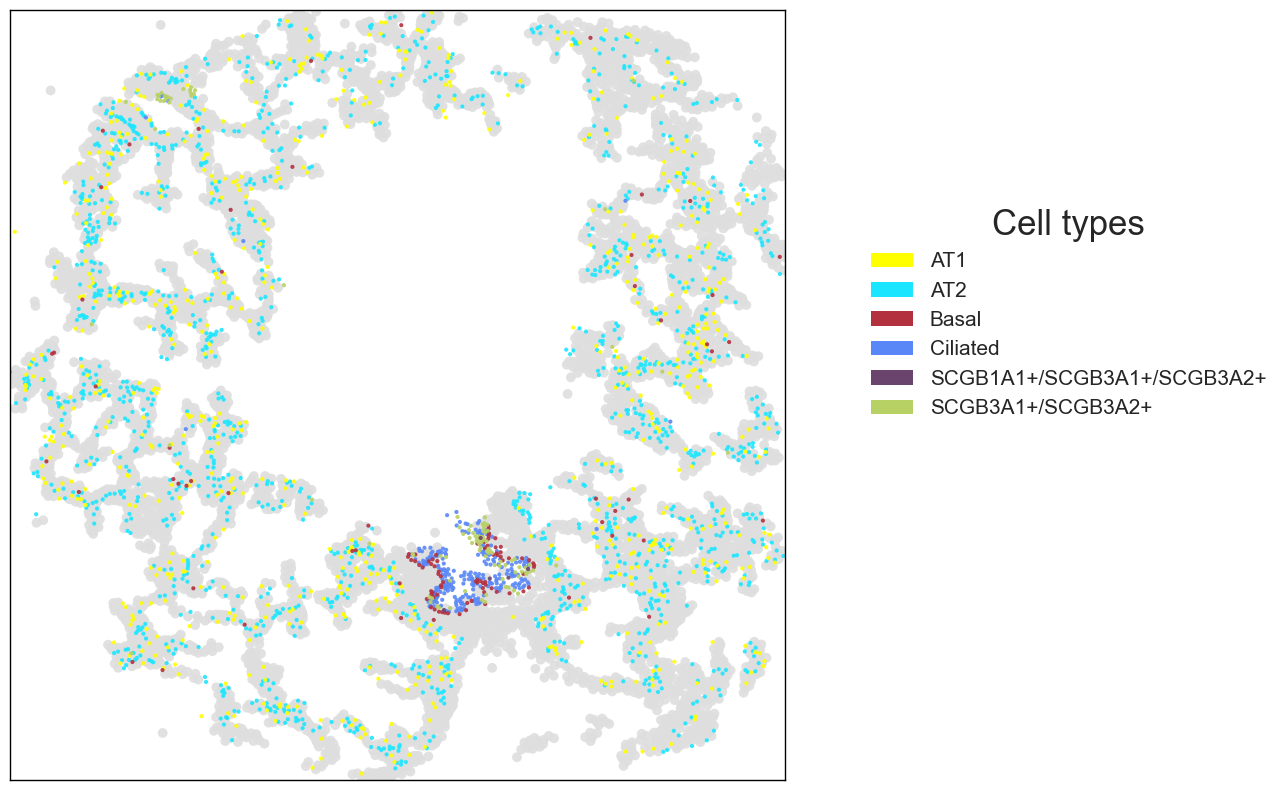

In [25]:
import tqdm

set_vis_default(font = 1.6, circle_marker = 5)

adata = sp_log.copy() 

vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 50


color_dict_ = {
    'Ciliated': '#5987f7',
    'SCGB3A1+/SCGB3A2+': '#b8d164',
    'SCGB1A1+/SCGB3A1+/SCGB3A2+': '#6b446e',
    'SMG duct': '#edb041',
    
    'Basal': '#b3303f',
#     'Aberrant Basaloid': '#ca1ddd',
}

color_dict.update(color_dict_)

sl_ct = [
    'AT2',                              
    'AT1',                               
    'Ciliated',                          
    'Basal',                             
    'SCGB3A1+/SCGB3A2+',                 
    'SCGB1A1+/SCGB3A1+/SCGB3A2+'
]

fig, axs = plt.subplots(1, 1, figsize=(10,10), gridspec_kw={'wspace': .2, 'hspace': 0.3})
ax = axs

cell_types = adata.obs[vis_col].unique()
remain_ct = [_ for _ in cell_types if _ not in sl_ct]
custom_palette = {}
for ct in remain_ct:
    custom_palette[ct] = '#DEDEDE'

for anchor_index in sl_ct:
    custom_palette[anchor_index] = color_dict[anchor_index]

    
ad_sc = adata
adata_remain = ad_sc[~ad_sc.obs[vis_col].isin(sl_ct)]
adata_sl = ad_sc[ad_sc.obs[vis_col].isin(sl_ct)]



sns.scatterplot(
    data=adata_remain.obs, 
    x="x_centroid", 
    y="y_centroid", 
    hue=vis_col, 
    s=50, linewidth = 0, 
    ax=ax, 
    palette = custom_palette, 
    alpha = 0.9
) 

for ct in sl_ct:
    s = 9
    sns.scatterplot(
        data=adata_sl[adata_sl.obs[vis_col].isin([ct])].obs, 
        x="x_centroid", 
        y="y_centroid", 
        hue=vis_col,
        s=s, linewidth = 0., edgecolor = 'black',
        ax=ax, 
        palette = custom_palette, 
        alpha = 0.9
    ) 


for spine in ['left', 'right', 'top', 'bottom']:
    axs.spines[spine].set_color('black')        
    axs.spines[spine].set_linewidth(1)

    
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xlim([adata.obs['x_centroid'].min(), adata.obs['x_centroid'].max()])
ax.set_ylim([adata.obs['y_centroid'].min(), adata.obs['y_centroid'].max()])
ax.invert_yaxis()
ax.legend_.remove()
ax.set_title('')


from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color) for key, color in color_dict.items() if (key in sl_ct) & (key not in ['SMCs'])]

legend_labels = [key for key, color in color_dict.items() if (key in sl_ct) & (key not in ['SMCs'])]
legend_labels = [_ if _ not in ['SMCs', 'Pericytes'] else 'SMCs/Pericytes' for _ in legend_labels]

plt.legend(
    legend_handles, legend_labels, title='Cell types', fontsize = 15, title_fontsize = 25,
    bbox_to_anchor=(1.4, .7), bbox_transform=plt.gcf().transFigure, loc='upper right'
)
# plt.savefig(f'./save_figs_si/spatial_sample_epi_116A.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=1)

plt.show()
plt.close()

# crop1

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


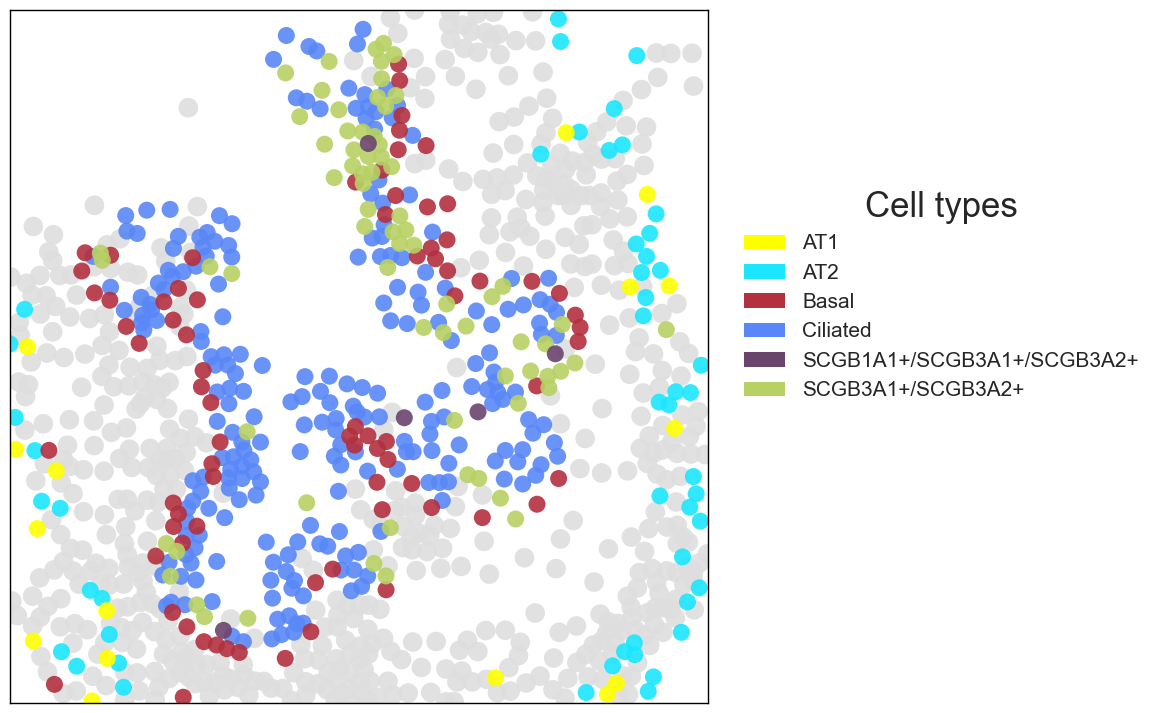

In [26]:
import tqdm

set_vis_default(font = 1.6, circle_marker = 5)

x_start = 1450 * sf
x_end = 1950 * sf
y_start = 2000 * sf
y_end = 2400 * sf

x_start = max(round(x_start), 0)
x_end = max(round(x_end), 0)
y_start = max(round(y_start), 0)
y_end = max(round(y_end), 0)


anno_use = sp_log.obs.copy()
cond_x = (anno_use['x_centroid'] >= x_start / sf) & (anno_use['x_centroid'] <= x_end / sf) 
cond_y = (anno_use['y_centroid'] >= y_start / sf) & (anno_use['y_centroid'] <= y_end / sf) 
cond = cond_x & cond_y
anno_crop = anno_use[cond]

sp_crop = sp_log[sp_log.obs.index.isin(anno_crop.index)].copy()

adata = sp_crop

vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 50

color_dict_ = {
    'Ciliated': '#5987f7',
    'SCGB3A1+/SCGB3A2+': '#b8d164',
    'SCGB1A1+/SCGB3A1+/SCGB3A2+': '#6b446e',
    'SMG duct': '#edb041',
    
    'Basal': '#b3303f',
#     'Aberrant Basaloid': '#ca1ddd',
}

color_dict.update(color_dict_)
sl_ct = [
    'AT2',                              
    'AT1',                               
    'Ciliated',                          
    'Basal',                             
    'SCGB3A1+/SCGB3A2+',                 
    'SCGB1A1+/SCGB3A1+/SCGB3A2+'
]

fig, axs = plt.subplots(1, 1, figsize=(9,9), gridspec_kw={'wspace': .2, 'hspace': 0.3})
ax = axs

cell_types = adata.obs[vis_col].unique()
remain_ct = [_ for _ in cell_types if _ not in sl_ct]
custom_palette = {}
for ct in remain_ct:
    custom_palette[ct] = '#DEDEDE'

for anchor_index in sl_ct:
    custom_palette[anchor_index] = color_dict[anchor_index]

    
ad_sc = adata
adata_remain = ad_sc[~ad_sc.obs[vis_col].isin(sl_ct)]
adata_sl = ad_sc[ad_sc.obs[vis_col].isin(sl_ct)]



sns.scatterplot(
    data=adata_remain.obs, 
    x="x_centroid", 
    y="y_centroid", 
    hue=vis_col, 
    s=200, linewidth = 0, 
    ax=ax, 
    palette = custom_palette, 
    alpha = 0.9
) 

for ct in sl_ct:
    s = 150
    sns.scatterplot(
        data=adata_sl[adata_sl.obs[vis_col].isin([ct])].obs, 
        x="x_centroid", 
        y="y_centroid", 
        hue=vis_col,
        s=s, linewidth = 0., edgecolor = 'black',
        ax=ax, 
        palette = custom_palette, 
        alpha = 0.9
    ) 

for spine in ['left', 'right', 'top', 'bottom']:
    axs.spines[spine].set_color('black')        
    axs.spines[spine].set_linewidth(1)

    
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xlim([adata.obs['x_centroid'].min(), adata.obs['x_centroid'].max()])
ax.set_ylim([adata.obs['y_centroid'].min(), adata.obs['y_centroid'].max()])
ax.invert_yaxis()
ax.legend_.remove()
ax.set_title('')


from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color) for key, color in color_dict.items() if (key in sl_ct) & (key not in ['SMCs'])]

legend_labels = [key for key, color in color_dict.items() if (key in sl_ct)]

plt.legend(
    legend_handles, legend_labels, title='Cell types', fontsize = 15, title_fontsize = 25,
    bbox_to_anchor=(1.4, .7), bbox_transform=plt.gcf().transFigure, loc='upper right'
)
# plt.savefig(f'./save_figs_si/spatial_sample_epi_116A_crop1.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=1)

plt.show()
plt.close()

## raw expr

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


Will show gene ['LTF', 'TP63', 'MUC5B', 'MUC5AC', 'SCGB1A1', 'SCGB3A2', 'FOXJ1']


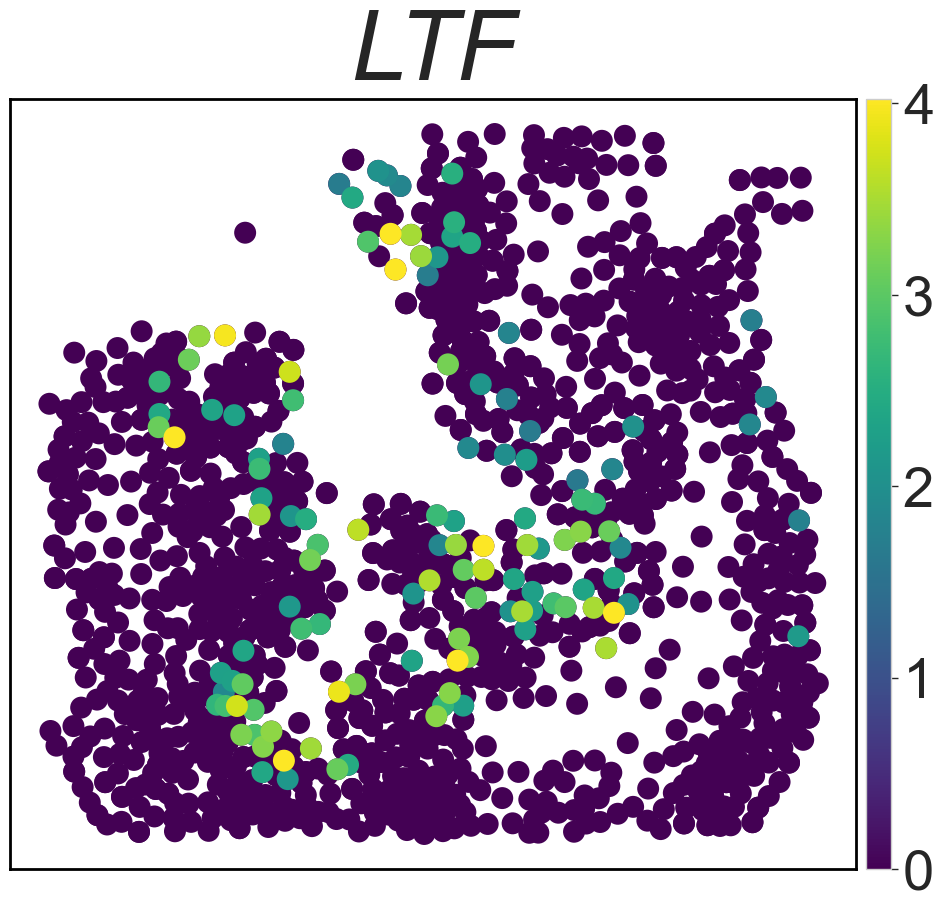

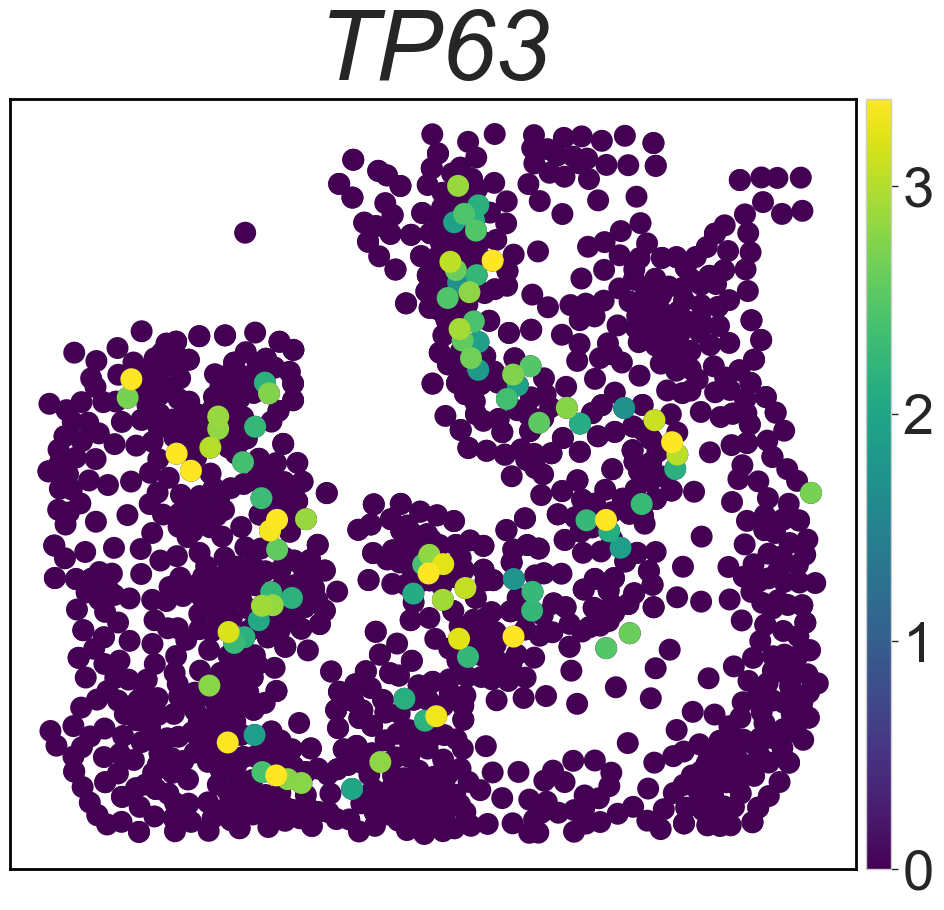

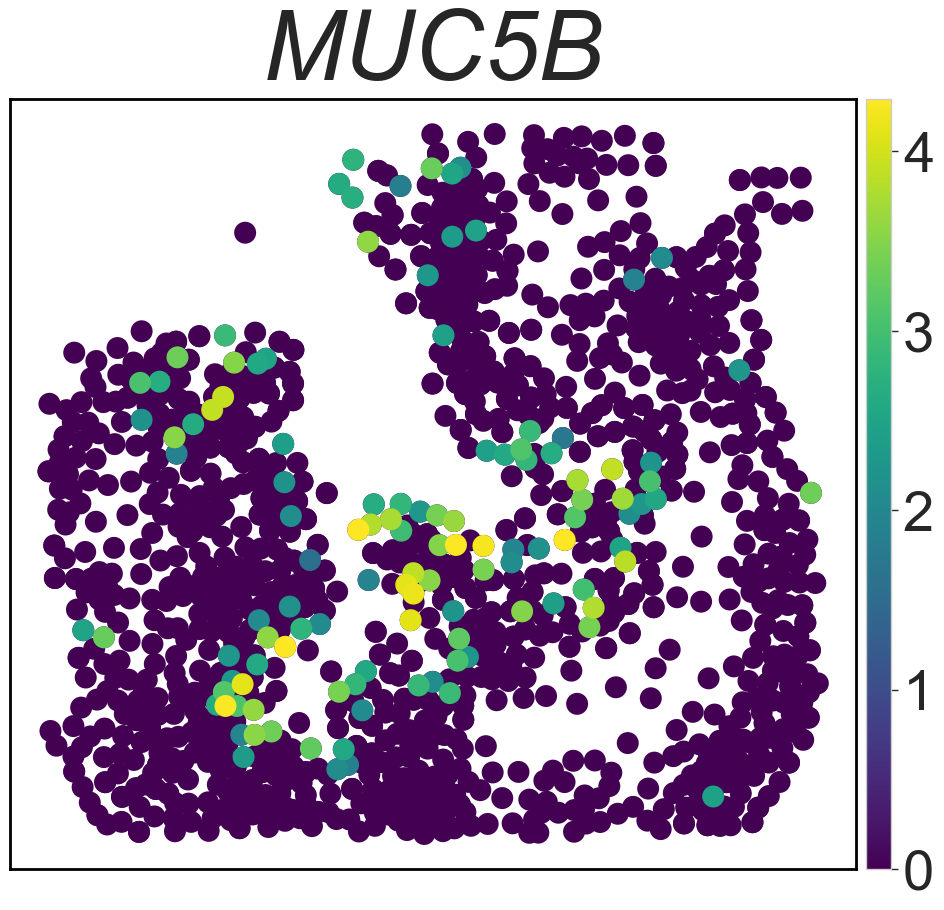

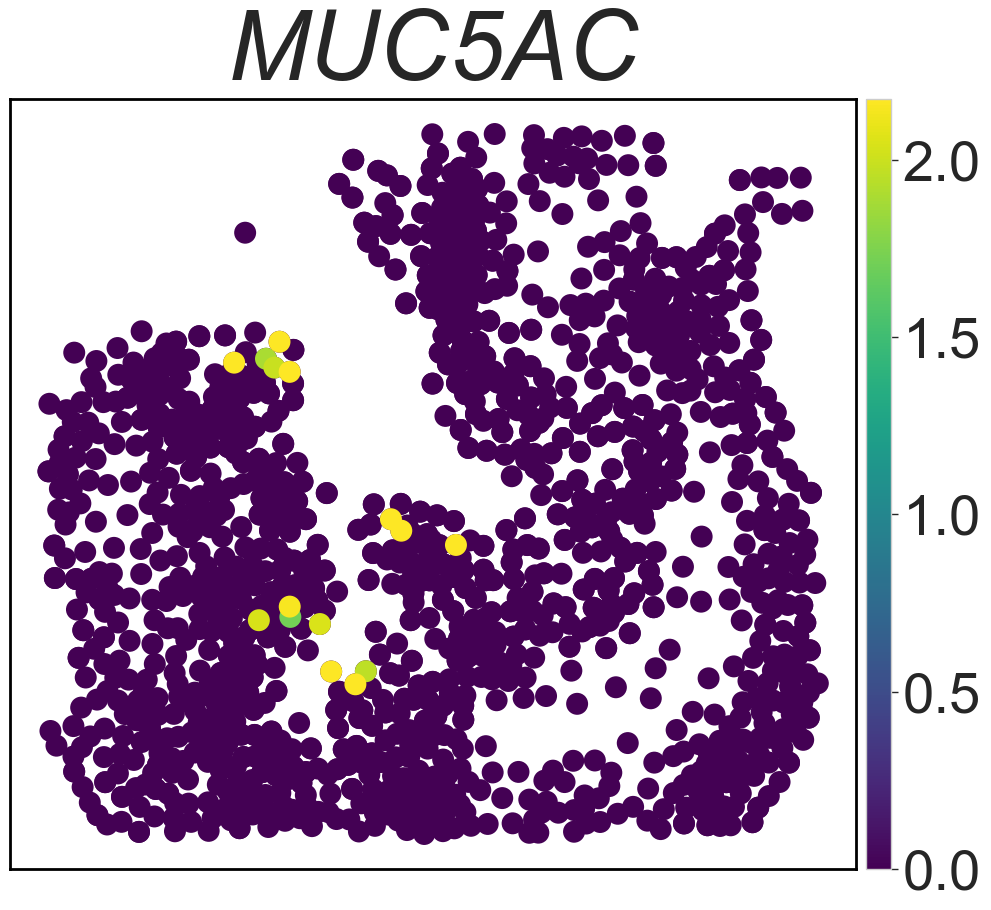

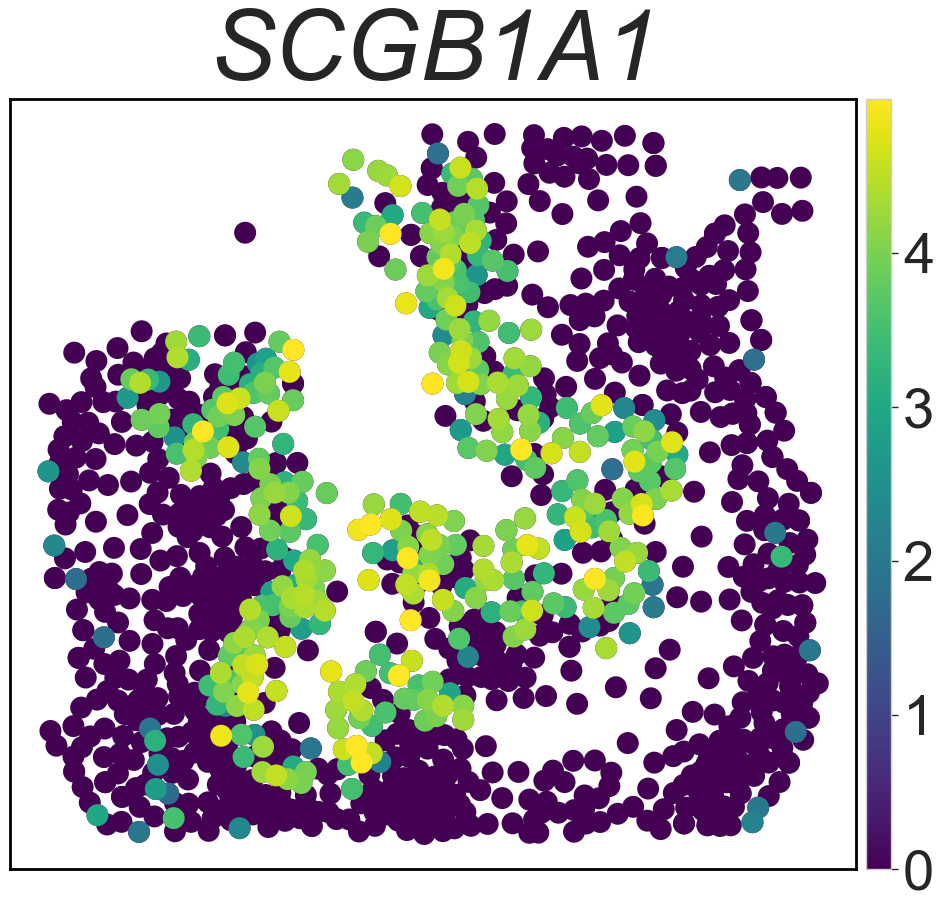

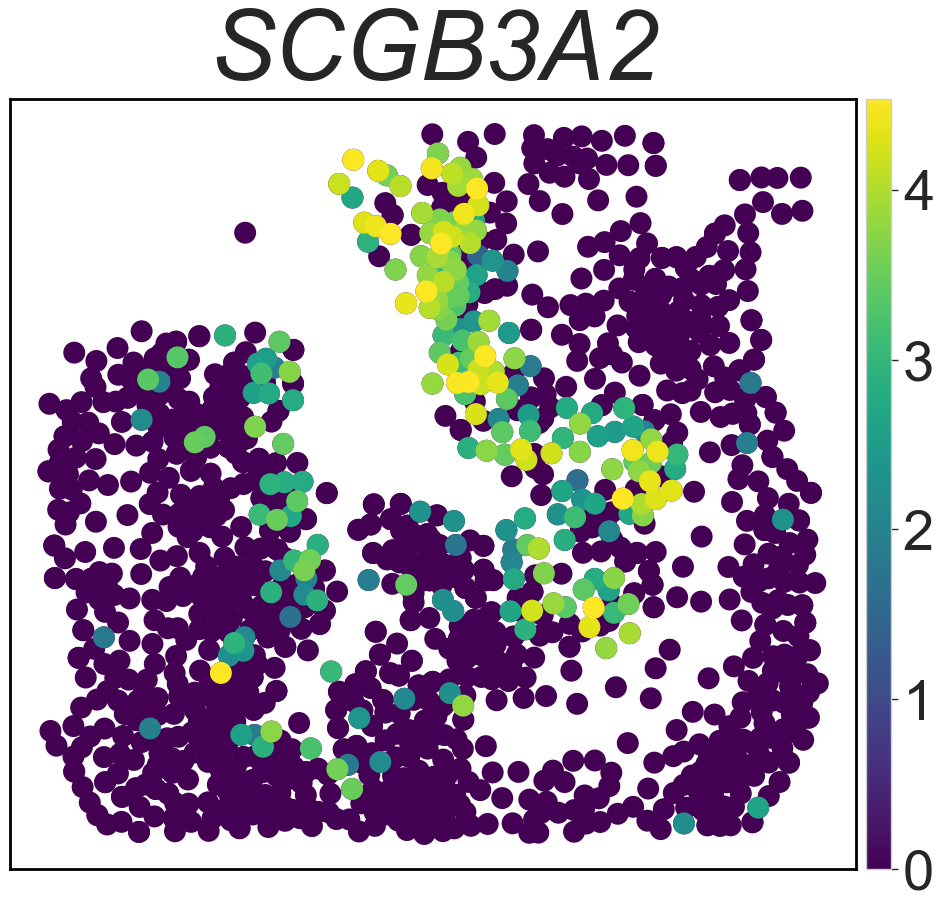

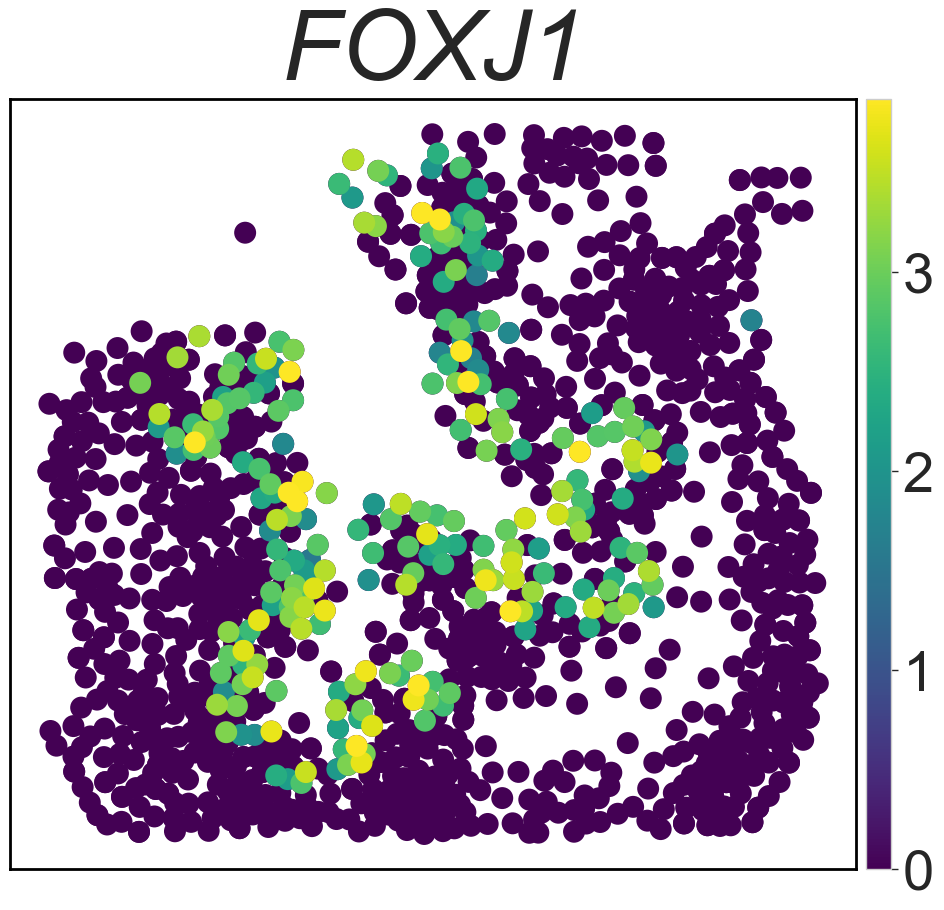

In [27]:
import tqdm

set_vis_default(font = 4.6, circle_marker = 5)


vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 40

glist = [
    'LTF', 'TP63', 
    'MUC5B', 'MUC5AC',
    'SCGB1A1', 'SCGB3A1', 'SCGB3A2', 'FOXJ1'

]
glist = [_ for _ in glist if _ in adata.var_names]
print(f'Will show gene {glist}')
for gene in glist:
    fig, ax = plt.subplots(1, 1, figsize=(12,10), gridspec_kw={'wspace': .2, 'hspace': 0.3})
    s = 1000
    sc.pl.embedding(
        adata=adata, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = 1e10,
        colorbar_loc = None,
        return_fig = False, show = False,
        title = ''
        
    ) 
#     ax.get_legend().remove()
    sc.pl.embedding(
        adata=adata_sl, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = np.quantile(np.array(adata[:, gene].X).squeeze(), .99),
        return_fig = False, show = False,
        title = ''
        
    ) 
    ax.invert_yaxis()
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_color('black')        
        ax.spines[spine].set_linewidth(2)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(gene, fontdict={'fontstyle': 'italic'}, fontsize = 70)

#     plt.savefig(f'./save_figs_si/markers_116A/crop1_{gene}.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.1)
    plt.show()
    plt.close()

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


Will show gene ['ITGA6', 'ITGB4']


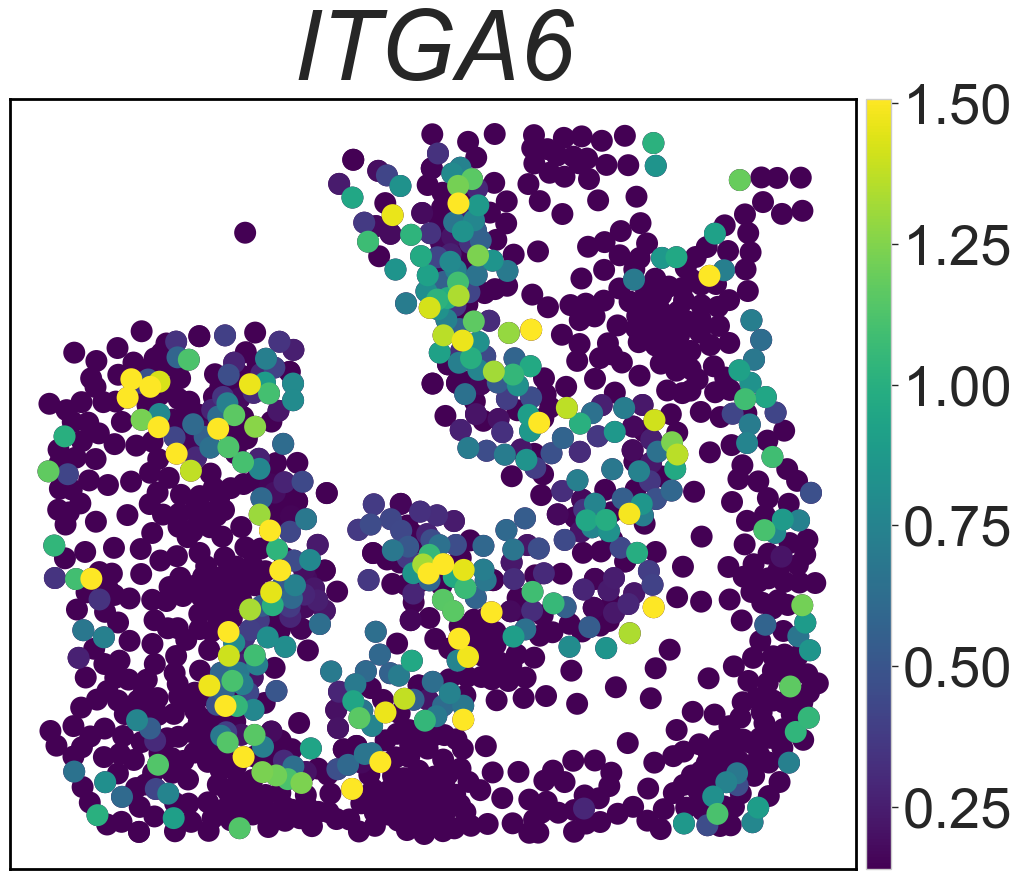

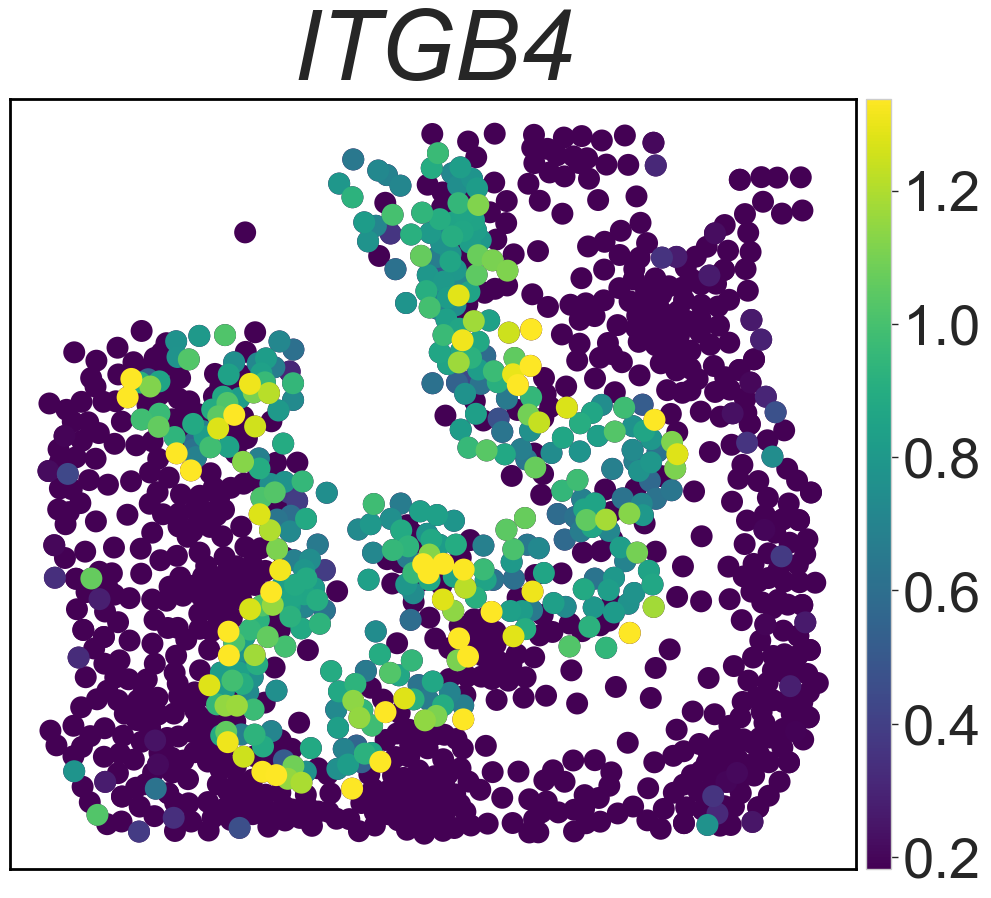

In [31]:
import tqdm

set_vis_default(font = 4.6, circle_marker = 5)



adata_inte_vis = adata_inte[adata_sl.obs.index].copy()
adata_inte_vis.X[adata_inte_vis.X < 0] = 0
vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 40

glist = [
    'ITGA6', 'ITGB4'

]
glist = [_ for _ in glist if _ in adata_inte_vis.var_names]
print(f'Will show gene {glist}')
for gene in glist:
    fig, ax = plt.subplots(1, 1, figsize=(12,10), gridspec_kw={'wspace': .2, 'hspace': 0.3})
    s = 1000
    sc.pl.embedding(
        adata=adata_inte[adata.obs.index], 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = 1e10,
        colorbar_loc = None,
        return_fig = False, show = False,
        title = ''
        
    ) 
    sc.pl.embedding(
        adata=adata_inte_vis, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
        vmin = np.quantile(np.array(adata_inte_vis[:, gene].X.A).squeeze(), .05),
        vmax = np.quantile(np.array(adata_inte_vis[:, gene].X.A).squeeze(), .95),
        return_fig = False, show = False,
        title = ''
        
    ) # , palette = custom_palette[:len(hue_order)], palette = color_dict
    ax.invert_yaxis()
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_color('black')        
        ax.spines[spine].set_linewidth(2)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(gene, fontdict={'fontstyle': 'italic'}, fontsize = 70)


#     plt.savefig(f'./save_figs_si/markers_116A/crop1_{gene}_imputed.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.1)
    plt.show()
    plt.close()

# crop2

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


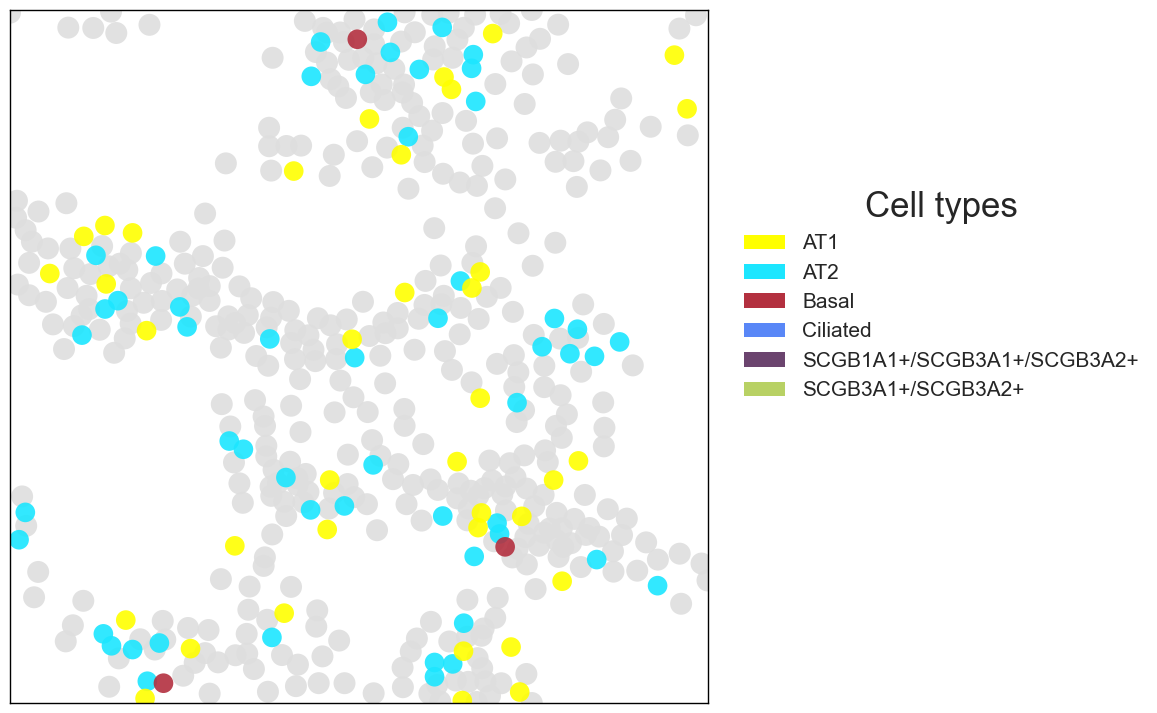

In [33]:
import tqdm

set_vis_default(font = 1.6, circle_marker = 5)

x_start = 2150 * sf
x_end = 2450 * sf
y_start = 750 * sf
y_end = 1250 * sf

x_start = max(round(x_start), 0)
x_end = max(round(x_end), 0)
y_start = max(round(y_start), 0)
y_end = max(round(y_end), 0)


anno_use = sp_log.obs.copy()
cond_x = (anno_use['x_centroid'] >= x_start / sf) & (anno_use['x_centroid'] <= x_end / sf) 
cond_y = (anno_use['y_centroid'] >= y_start / sf) & (anno_use['y_centroid'] <= y_end / sf) 
cond = cond_x & cond_y
anno_crop = anno_use[cond]

sp_crop = sp_log[sp_log.obs.index.isin(anno_crop.index)].copy()
adata = sp_crop


vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 50


color_dict_ = {
    'Ciliated': '#5987f7',
    'SCGB3A1+/SCGB3A2+': '#b8d164',
    'SCGB1A1+/SCGB3A1+/SCGB3A2+': '#6b446e',
    'SMG duct': '#edb041',
    
    'Basal': '#b3303f',
#     'Aberrant Basaloid': '#ca1ddd',
}

color_dict.update(color_dict_)

sl_ct = [
    'AT2',                              
    'AT1',                               
    'Ciliated',                          
    'Basal',                             
    'SCGB3A1+/SCGB3A2+',                 
    'SCGB1A1+/SCGB3A1+/SCGB3A2+'
]

fig, axs = plt.subplots(1, 1, figsize=(9,9), gridspec_kw={'wspace': .2, 'hspace': 0.3})
ax = axs

cell_types = adata.obs[vis_col].unique()
remain_ct = [_ for _ in cell_types if _ not in sl_ct]
custom_palette = {}
for ct in remain_ct:
    custom_palette[ct] = '#DEDEDE'

for anchor_index in sl_ct:
    custom_palette[anchor_index] = color_dict[anchor_index]

    
ad_sc = adata
adata_remain = ad_sc[~ad_sc.obs[vis_col].isin(sl_ct)]
adata_sl = ad_sc[ad_sc.obs[vis_col].isin(sl_ct)]


sns.scatterplot(
    data=adata_remain.obs, 
    x="x_centroid", 
    y="y_centroid", 
    hue=vis_col, 
    s=250, linewidth = 0, 
    ax=ax, 
    palette = custom_palette, 
    alpha = 0.9
) # , palette = custom_palette[:len(hue_order)], palette = color_dict

for ct in sl_ct:
    s = 200
    sns.scatterplot(
        data=adata_sl[adata_sl.obs[vis_col].isin([ct])].obs, 
        x="x_centroid", 
        y="y_centroid", 
        hue=vis_col,
        s=s, linewidth = 0., edgecolor = 'black',
        ax=ax, 
        palette = custom_palette, 
        alpha = 0.9
    ) # , palette = custom_palette[:len(hue_order)], palette = color_dict


for spine in ['left', 'right', 'top', 'bottom']:
    axs.spines[spine].set_color('black')        
    axs.spines[spine].set_linewidth(1)

    
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_xlim([adata.obs['x_centroid'].min(), adata.obs['x_centroid'].max()])
ax.set_ylim([adata.obs['y_centroid'].min(), adata.obs['y_centroid'].max()])
ax.invert_yaxis()
ax.legend_.remove()
ax.set_title('')


from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color) for key, color in color_dict.items() if (key in sl_ct) & (key not in ['SMCs'])]

legend_labels = [key for key, color in color_dict.items() if (key in sl_ct)]

plt.legend(
    legend_handles, legend_labels, title='Cell types', fontsize = 15, title_fontsize = 25,
    bbox_to_anchor=(1.4, .7), bbox_transform=plt.gcf().transFigure, loc='upper right'
)
# plt.savefig(f'./save_figs_si/spatial_sample_epi_116A_crop2.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=1)

plt.show()
plt.close()

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


Will show gene ['AGER', 'SFTPC', 'PGC', 'LAMP3', 'NAPSA', 'SFTPD']


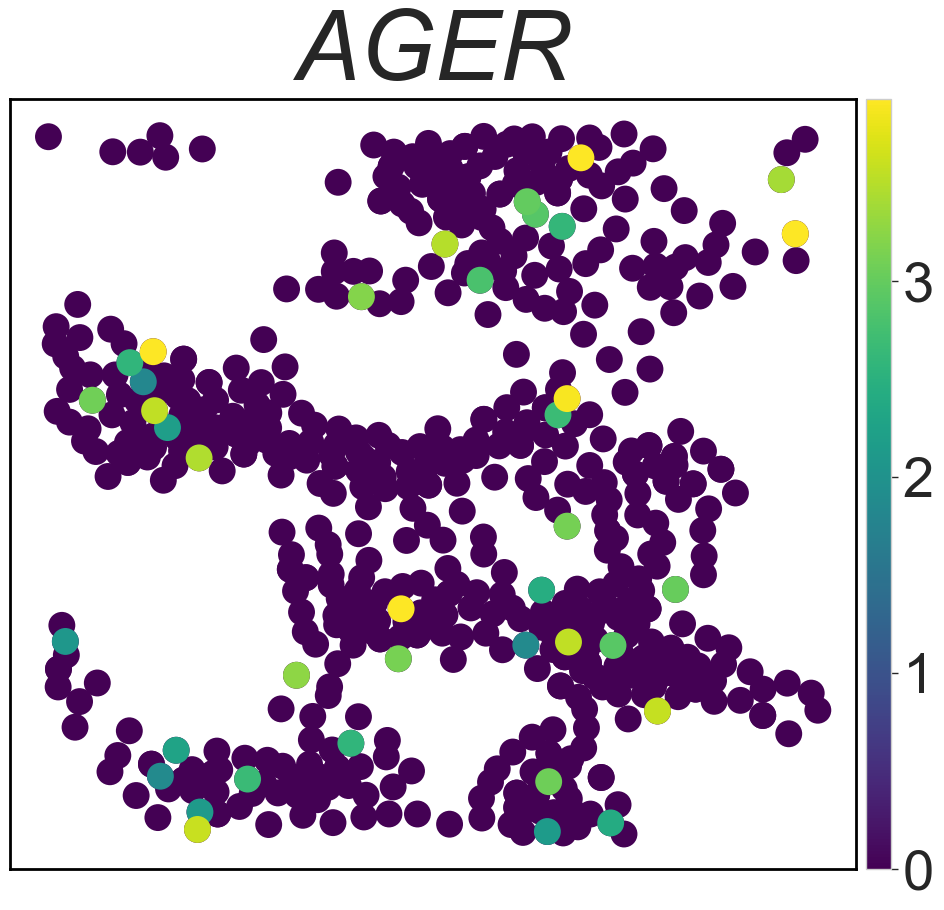

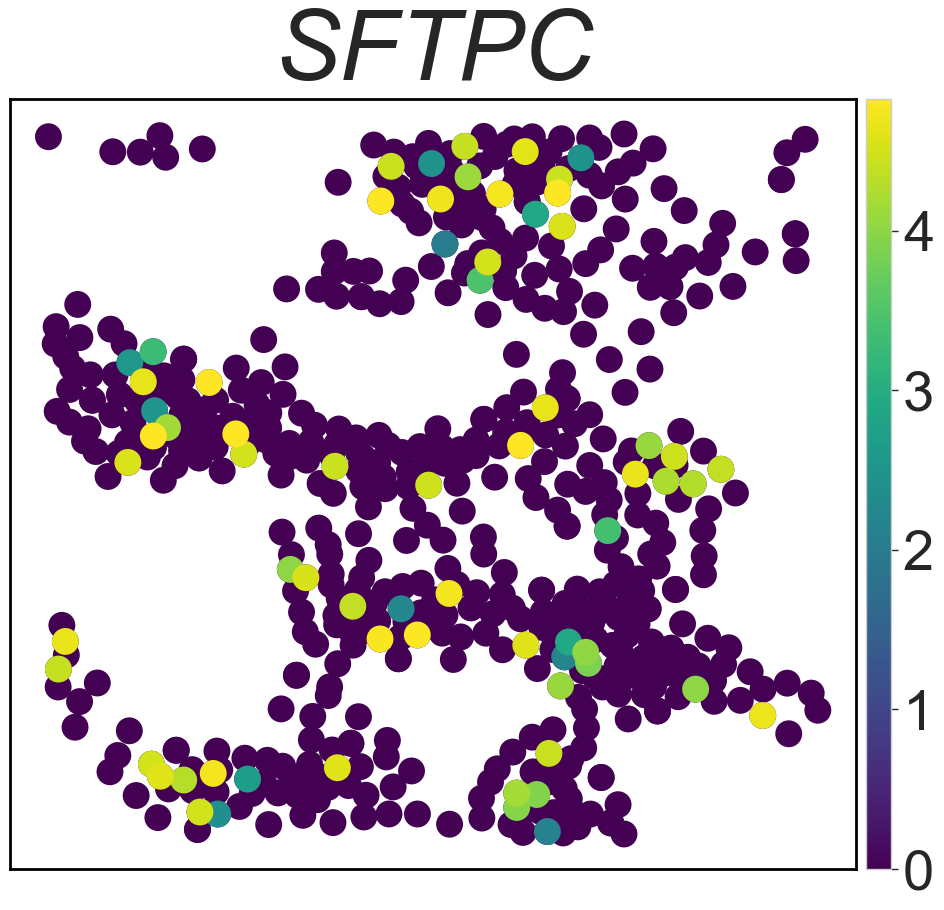

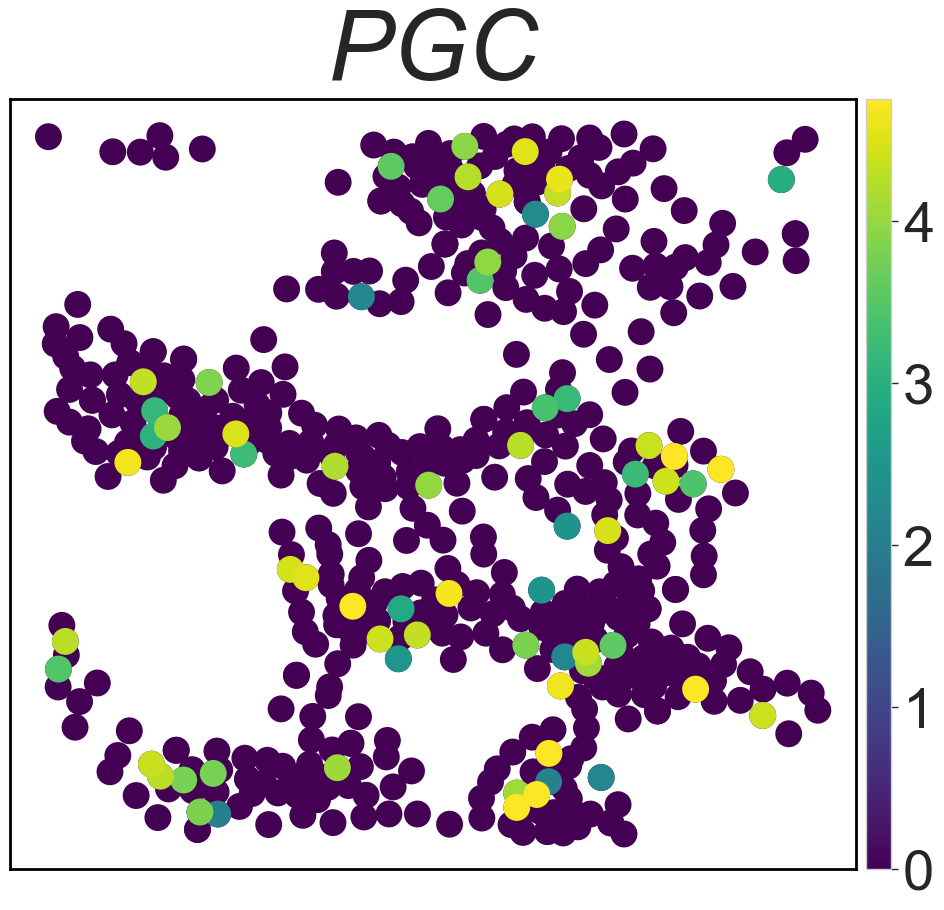

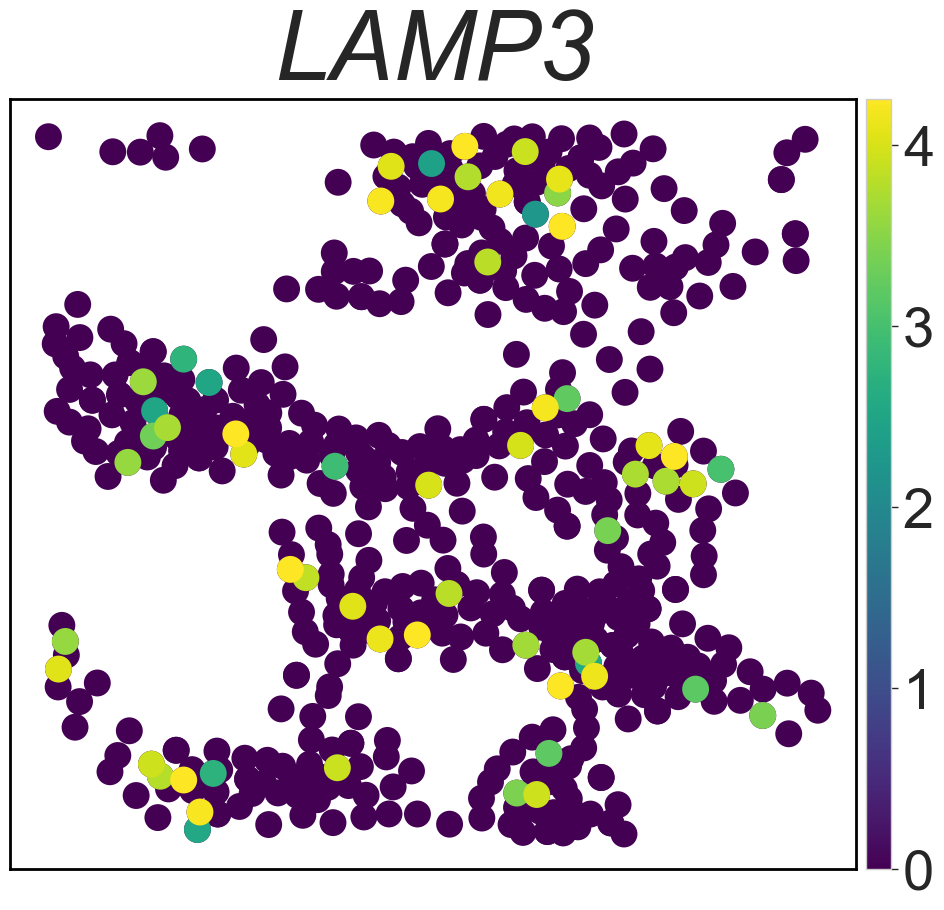

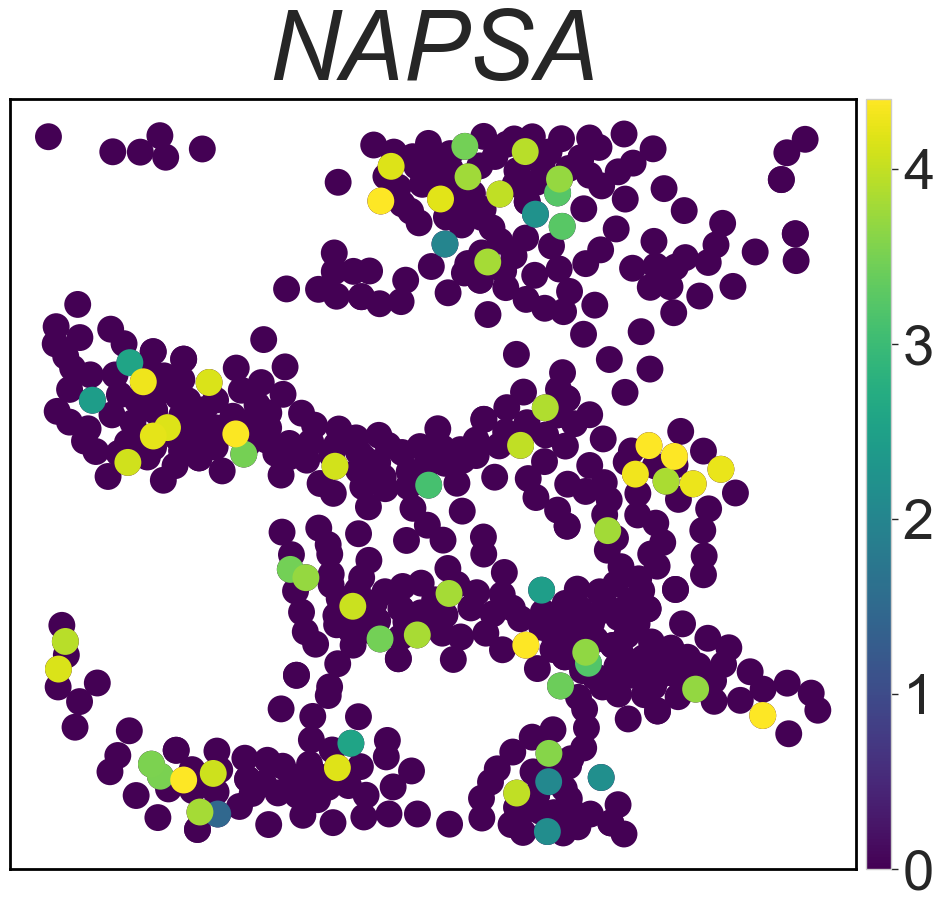

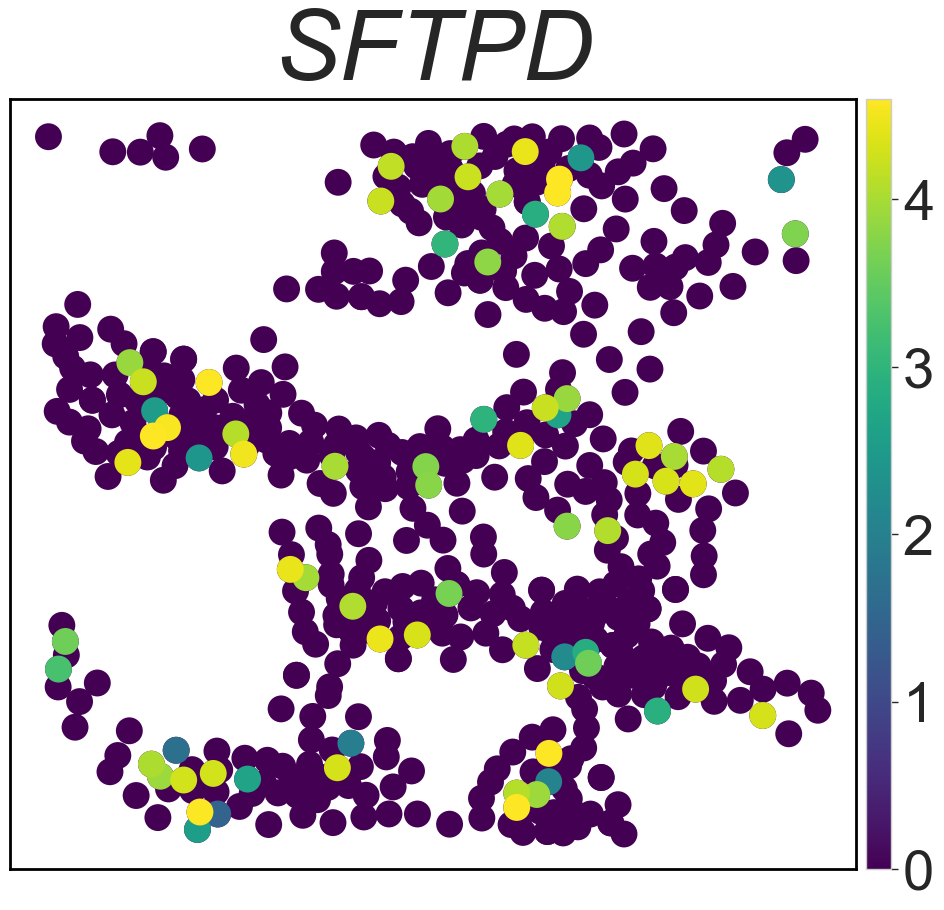

In [34]:
import tqdm

set_vis_default(font = 4.6, circle_marker = 5)


vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 40

glist = [
    'AGER', 'CAV1', 
    'SFTPC', 'ABCA3', 'PGC', 'WIF1', 'LAMP3', 'SFTPA2', 'NAPSA', 'SFTPD'

]
glist = [_ for _ in glist if _ in adata.var_names]
print(f'Will show gene {glist}')
for gene in glist:
    fig, ax = plt.subplots(1, 1, figsize=(12,10), gridspec_kw={'wspace': .2, 'hspace': 0.3})
    if gene == 'PTGDS':
        s = 40
    elif gene == 'MFAP5':
        s = 120
    else:
        s = 1500
    sc.pl.embedding(
        adata=adata, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = 1e10,
        colorbar_loc = None,
        return_fig = False, show = False,
        title = ''
        
    ) 
    sc.pl.embedding(
        adata=adata_sl, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = np.quantile(np.array(adata[:, gene].X).squeeze(), .99),
        return_fig = False, show = False,
        title = ''
        
    ) # , palette = custom_palette[:len(hue_order)], palette = color_dict
    ax.invert_yaxis()
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_color('black')        
        ax.spines[spine].set_linewidth(2)


    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(gene, fontdict={'fontstyle': 'italic'}, fontsize = 70)


#     plt.savefig(f'./save_figs_si/markers_116A/crop2_{gene}.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.1)
    plt.show()
    plt.close()

/tmp/ipykernel_3448480/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


Will show gene ['AGER', 'CAV1', 'SFTPC', 'ABCA3', 'PGC', 'WIF1', 'LAMP3', 'SFTPA2', 'NAPSA', 'SFTPD']


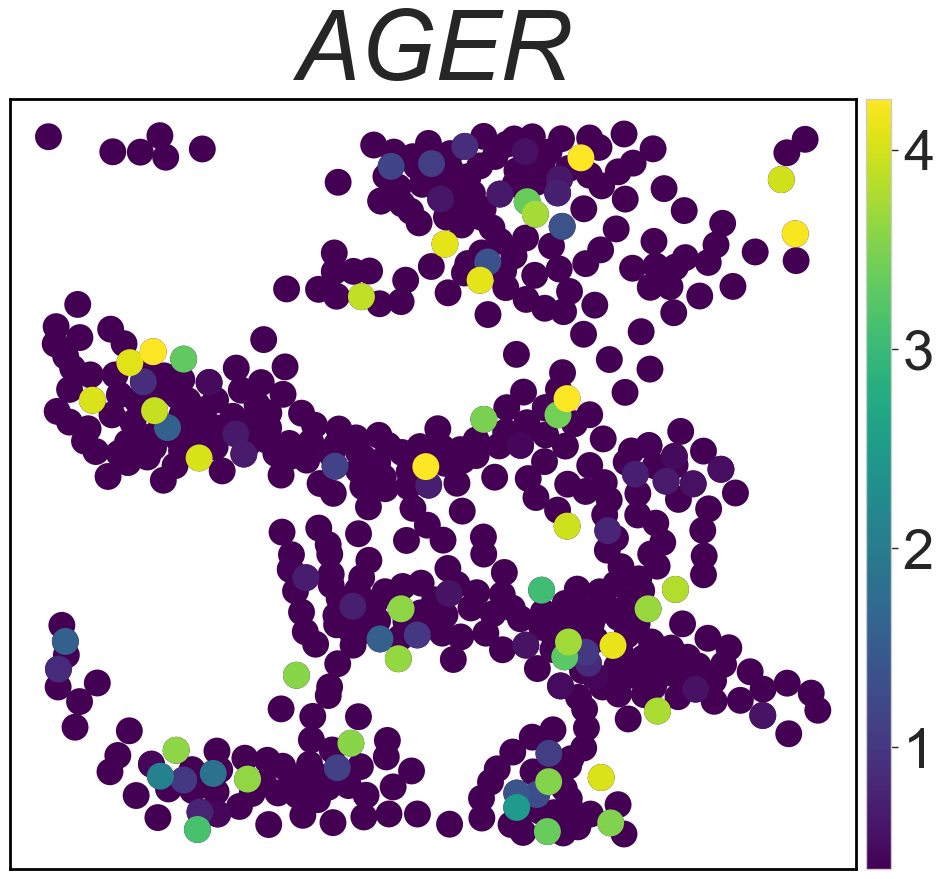

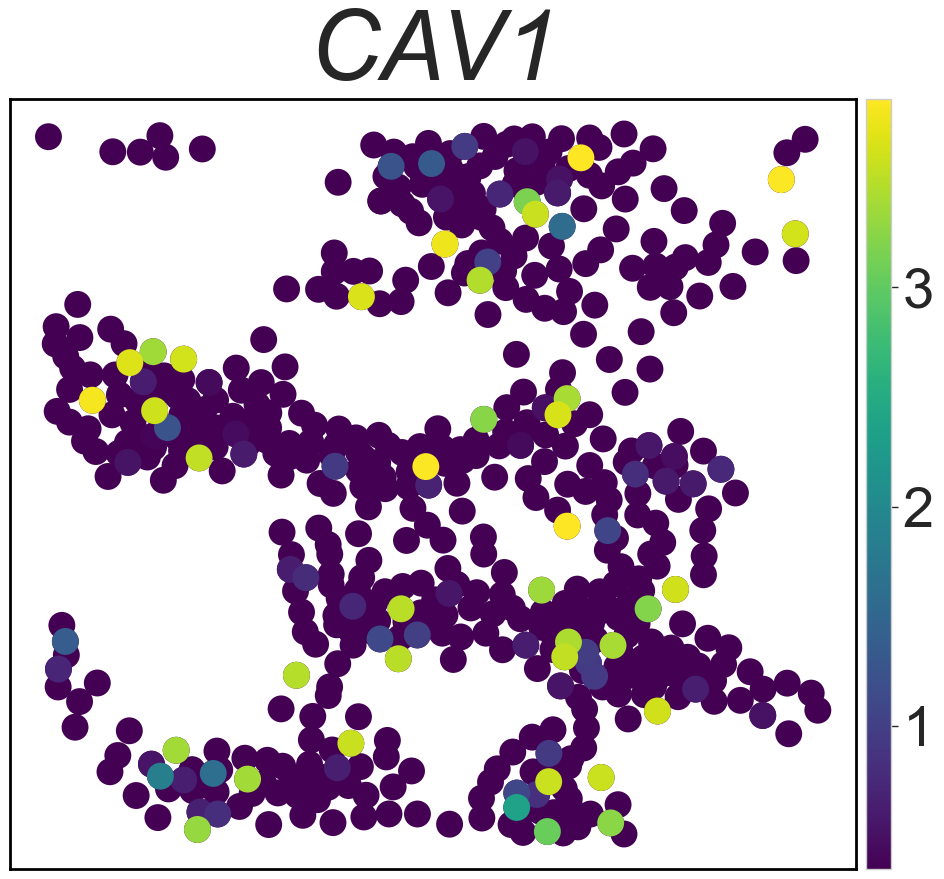

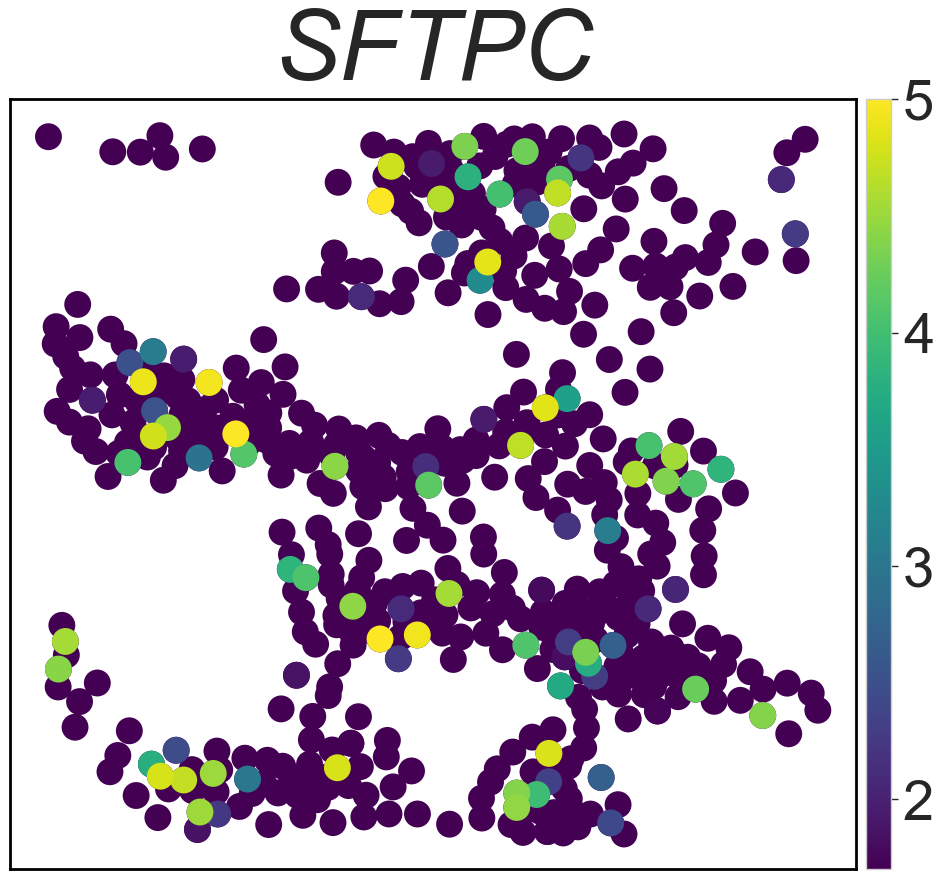

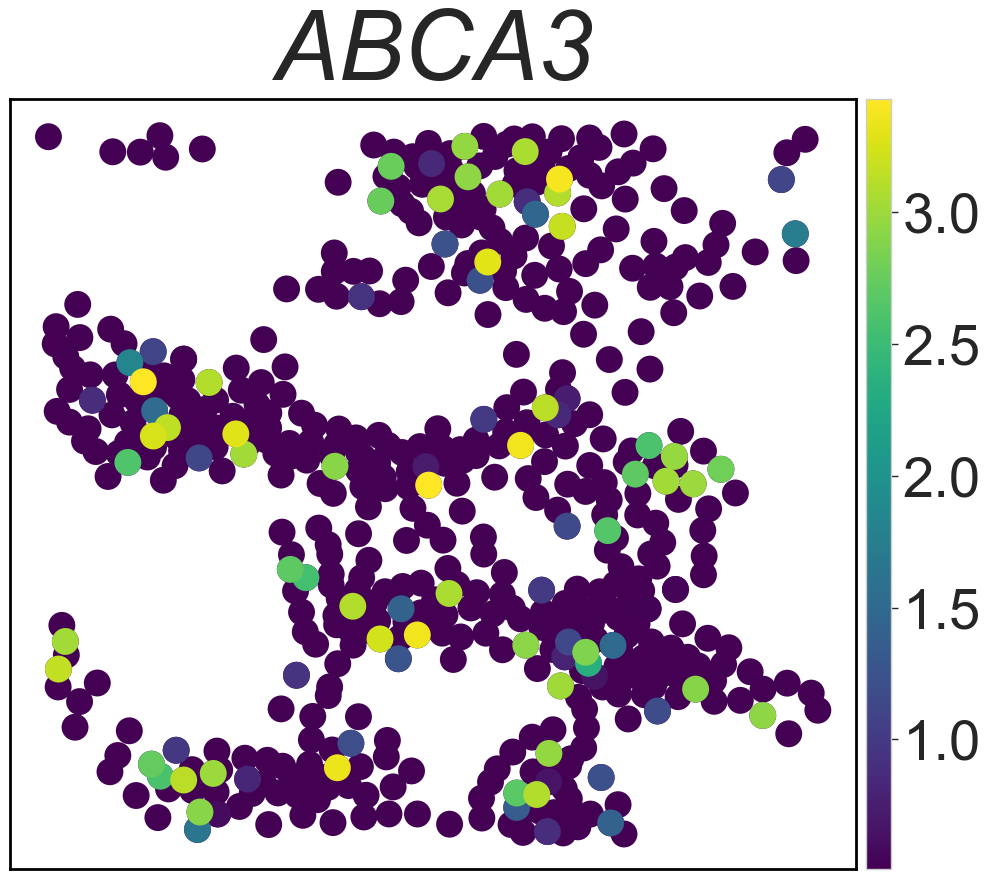

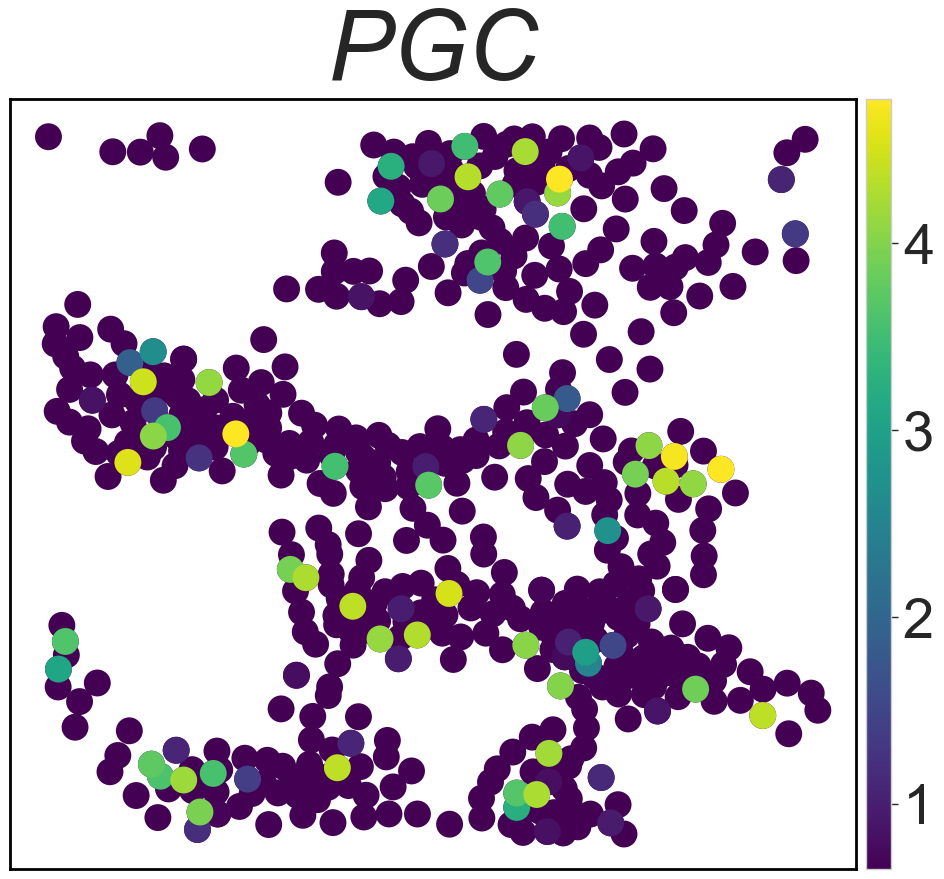

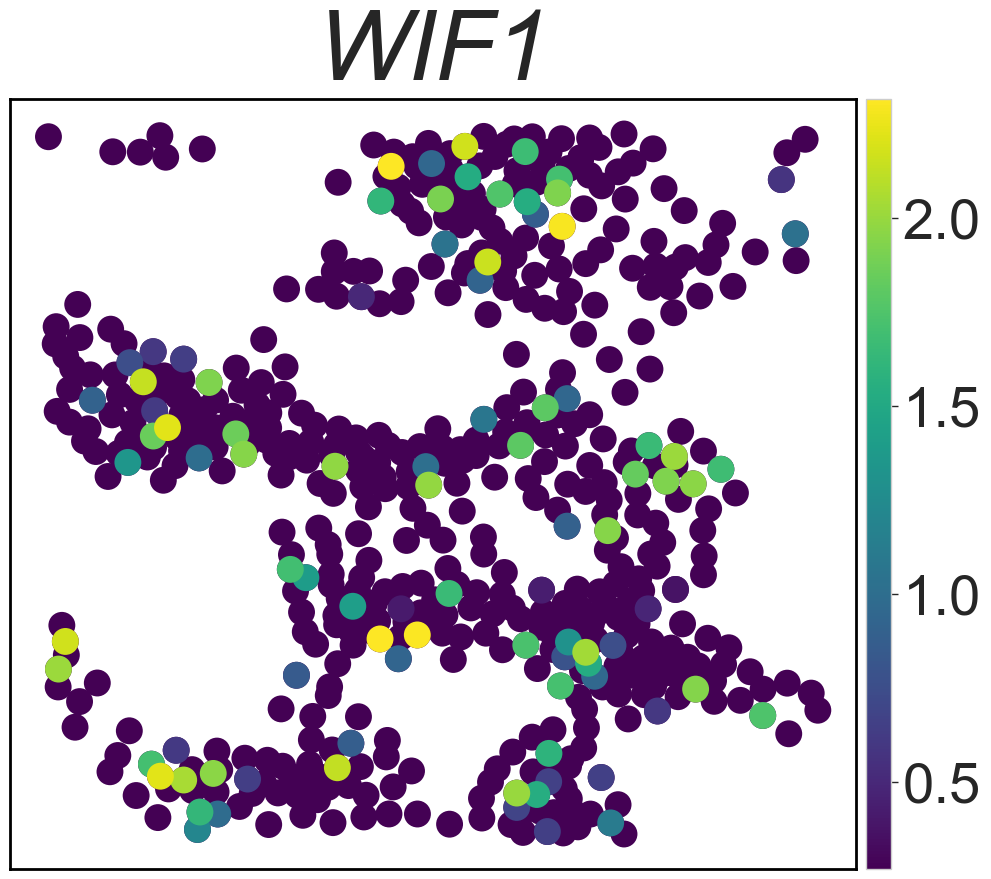

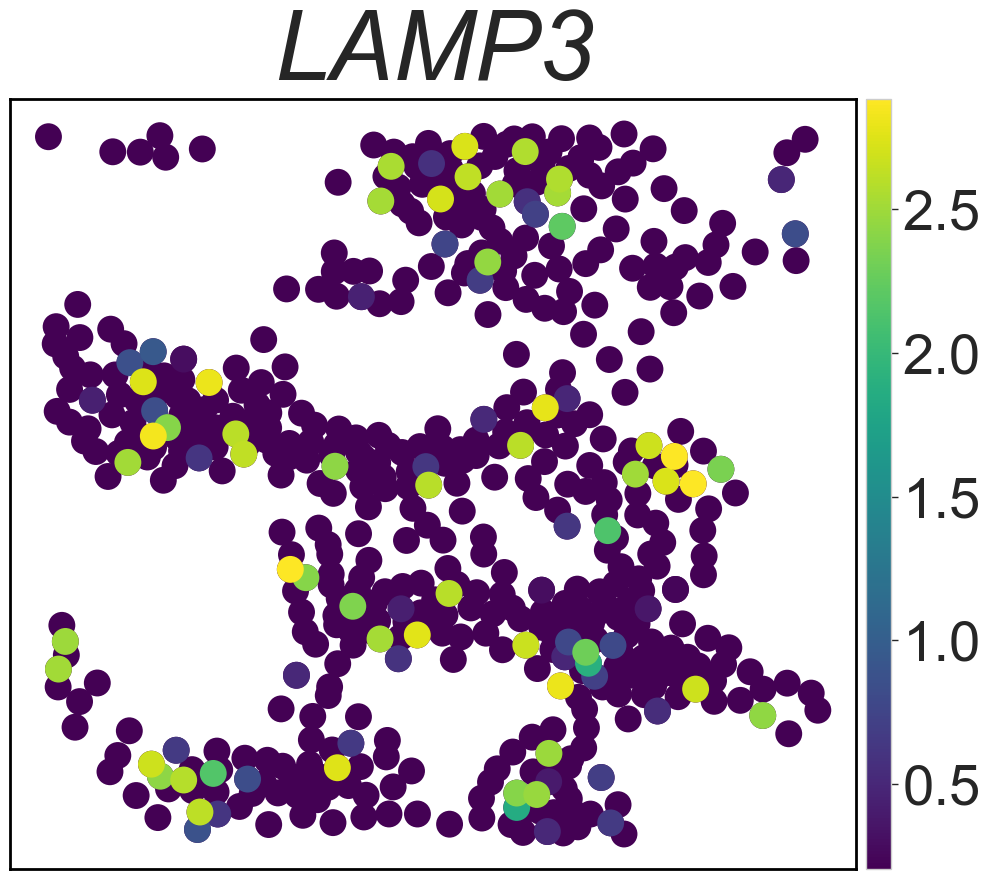

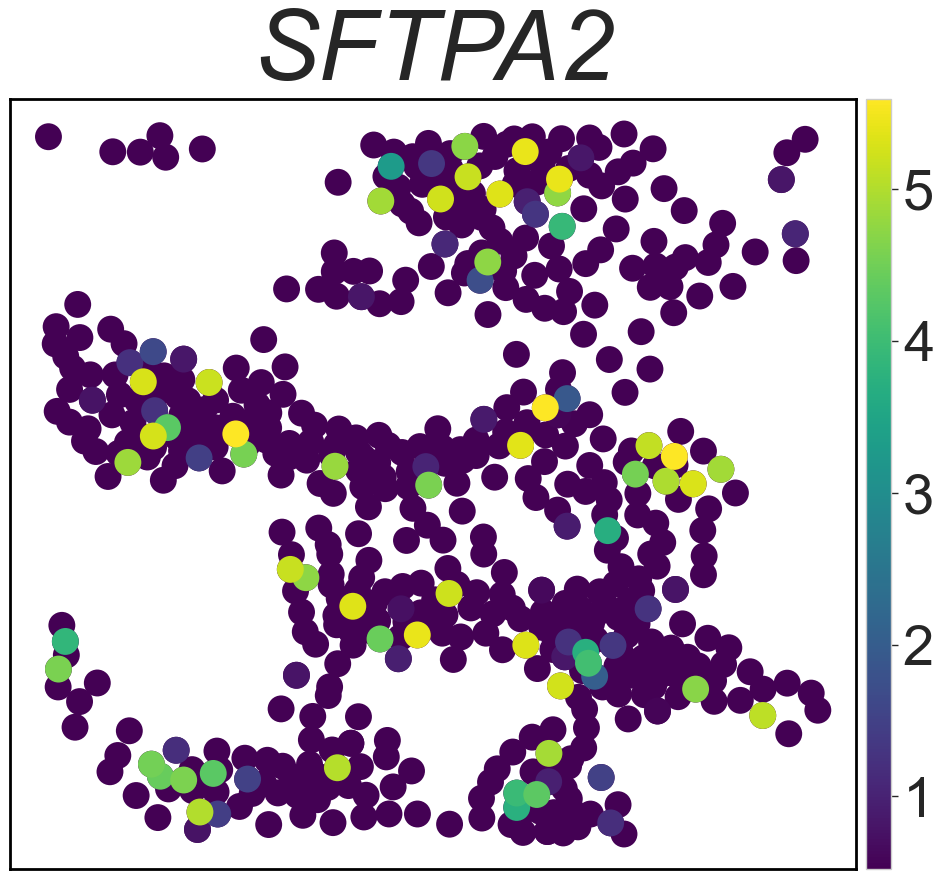

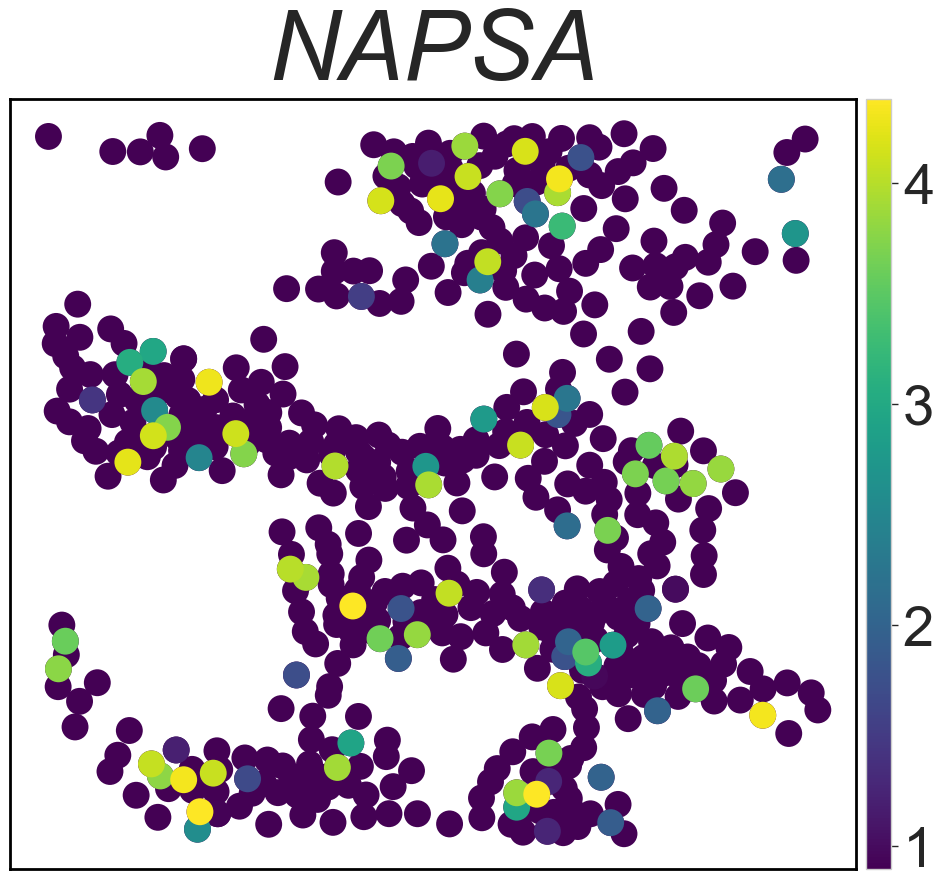

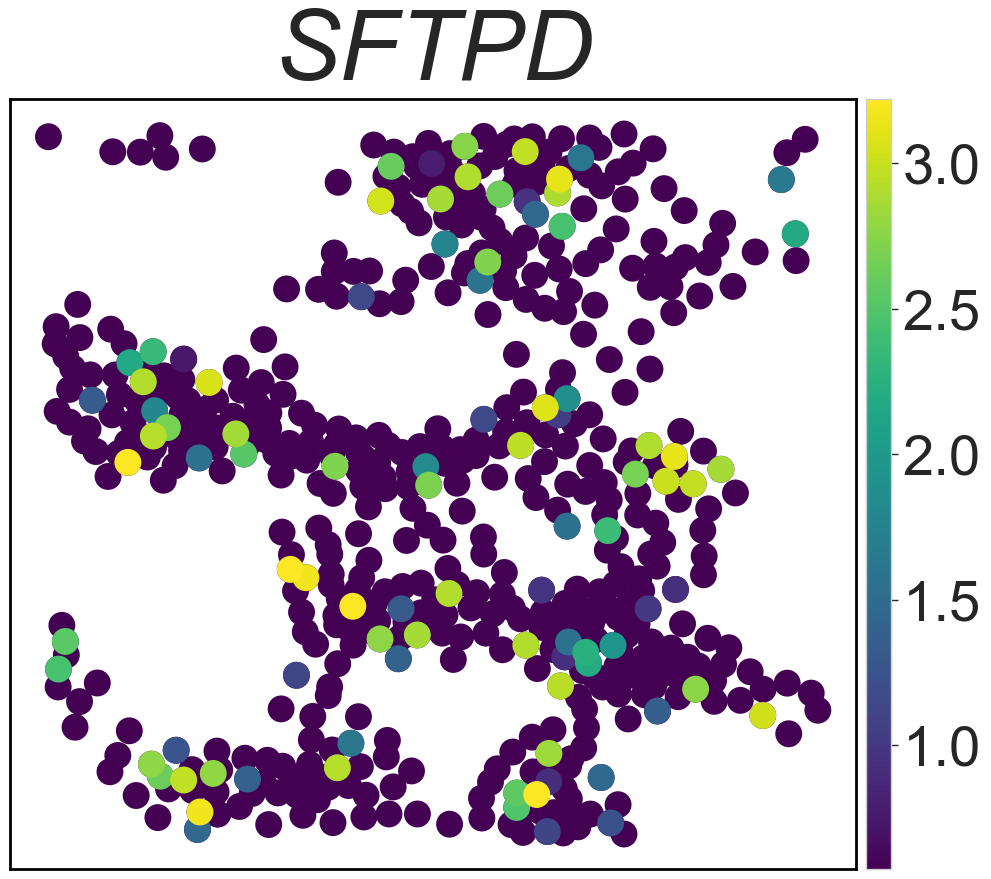

In [35]:
import tqdm

set_vis_default(font = 4.6, circle_marker = 5)



adata_inte_vis = adata_inte[adata_sl.obs.index].copy()
adata_inte_vis.X[adata_inte_vis.X < 0] = 0
vis_col = 'pred_atlas'
bbox_to_anchor = (1.6, 1.)
s = 40

glist = [
    'AGER', 'CAV1', 
    'SFTPC', 'ABCA3', 'PGC', 'WIF1', 'LAMP3', 'SFTPA2', 'NAPSA', 'SFTPD'

]
glist = [_ for _ in glist if _ in adata_inte_vis.var_names]

print(f'Will show gene {glist}')
for gene in glist:
    fig, ax = plt.subplots(1, 1, figsize=(12,10), gridspec_kw={'wspace': .2, 'hspace': 0.3})
    s = 1500
    sc.pl.embedding(
        adata=adata_inte[adata.obs.index], 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
#         vmin = np.quantile(np.array(adata[:, gene].X).squeeze(), .01),
        vmax = 1e10,
        colorbar_loc = None,
        return_fig = False, show = False,
        title = ''
        
    ) 
    sc.pl.embedding(
        adata=adata_inte_vis, 
        basis = 'spatial',
        color=gene,
        s=s, linewidth = 0.0, edgecolor = 'black',
        ax=ax, 
    #     palette = custom_palette, 
        cmap = 'viridis', 
    #     vmax = 2,
        alpha = 1.,
        vmin = np.quantile(np.array(adata_inte_vis[:, gene].X.A).squeeze(), .01),
        vmax = np.quantile(np.array(adata_inte_vis[:, gene].X.A).squeeze(), .98),
        return_fig = False, show = False,
        title = ''
        
    ) # , palette = custom_palette[:len(hue_order)], palette = color_dict
    ax.invert_yaxis()
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_color('black')        
        ax.spines[spine].set_linewidth(2)


    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(gene, fontdict={'fontstyle': 'italic'}, fontsize = 70)


#     plt.savefig(f'./save_figs_si/markers_116A/crop2_{gene}_imputed.png', format='png', dpi = 200, bbox_inches='tight',pad_inches=.1)
    plt.show()
    plt.close()